In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
ruta = r"C:\Users\Home\Desktop\proyecto-ciencia-de-datos\data\Connacionales_inscritos_en_el_Registro_Ciudadano_en_Línea_20260514.xlsx"

df = pd.read_excel(ruta)

In [ ]:
# Ver primeras filas
print(df.head())
print("------------------------------")

# Ver información general
print("Información General")
print(df.info())
print("------------------------------")

# Ver dimensiones
print("Dimension del dataset")
print(df.shape)
print("------------------------------")

# Ver datos nulos
print("Datos Nulos: ")
print(df.isnull().sum()) # Datos nulos = 35
print("------------------------------")

# Ver datos Duplicados
print("Datos Duplicados: ")
print(df.duplicated().sum()) # Duplicados = 0
print("------------------------------")
# No hay Datos Duplicados

         País Código ISO país      Ciudad de Residencia  \
0  AFGANISTAN             AFG  BADAKHSHAN/BARREH BARREH   
1  AFGANISTAN             AFG          BADAKHSHAN/BUCHI   
2  AFGANISTAN             AFG               KABOL/KABUL   
3  AFGANISTAN             AFG               KABOL/KABUL   
4  AFGANISTAN             AFG               KABOL/KABUL   

  Oficina de circunscripción consular  Edad (años)  \
0                      C. NUEVA DELHI           25   
1                      C. NUEVA DELHI           37   
2                      C. NUEVA DELHI           34   
3                      C. NUEVA DELHI           35   
4                      C. NUEVA DELHI           45   

                              Área Conocimiento  Nivel Académico Estado civil  \
0                                       NINGUNA     BACHILLERATO      SOLTERO   
1  ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES  SIN INFORMACIÓN  DESCONOCIDO   
2   CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN         MAESTRÍA      SOLTERO

In [5]:
# Eliminamos columnas Inutiles
columnas_eliminar = [
    "Código ISO país",
    "Localización",
    "Fecha de Registro"
]

df = df.drop(columns=columnas_eliminar)

print("Verificamos que si eliminamos las columnas inutiles")
print(df.columns)
print("------------------------------")

# Verificamos dimensiones Antes de Limpieza
print(df.shape)
print("------------------------------")

Verificamos que si eliminamos las columnas inutiles
Index(['País', 'Ciudad de Residencia', 'Oficina de circunscripción consular',
       'Edad (años)', 'Área Conocimiento', 'Nivel Académico', 'Estado civil',
       'Sexo', 'Pertenencia étnica', 'Ciudad de Nacimiento',
       'Cantidad de personas'],
      dtype='str')
------------------------------
(1833558, 11)
------------------------------


In [6]:
# Verificamos balance de la variable
print(df["Área Conocimiento"].value_counts())
print("------------------------------")

Área Conocimiento
NINGUNA                                                  981297
NO INDICA                                                226811
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             152037
INGENIERÍA, ARQUITECTURA Y AFINES                        120974
CIENCIAS DE LA SALUD                                      82161
CIENCIAS SOCIALES Y HUMANAS                               75423
BELLAS ARTES                                              35006
CIENCIAS DE LA EDUCACIÓN                                  33525
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                      28956
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                      19856
SALUD Y BIENESTAR                                         16237
MATEMÁTICAS Y CIENCIAS NATURALES                          12059
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN                9792
EDUCACIÓN                                                  6329
ARTES Y HUMANIDADES                                        6136
COCINA Y CULINARIA    

In [7]:
# existen demasiados datos clasificados como ninguno, no indica y no aplica
categorias_invalidas = [
    "NINGUNA",
    "NO INDICA",
    "(NO REGISTRA)"
]

df = df[~df["Área Conocimiento"].isin(categorias_invalidas)]

# Verificamos de nuevo balance de clases sin datos que no contengan nada
print(df["Área Conocimiento"].value_counts())
print("------------------------------\n")
print("Despues de limpieza: ", df.shape)

Área Conocimiento
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             152037
INGENIERÍA, ARQUITECTURA Y AFINES                        120974
CIENCIAS DE LA SALUD                                      82161
CIENCIAS SOCIALES Y HUMANAS                               75423
BELLAS ARTES                                              35006
CIENCIAS DE LA EDUCACIÓN                                  33525
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                      28956
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                      19856
SALUD Y BIENESTAR                                         16237
MATEMÁTICAS Y CIENCIAS NATURALES                          12059
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN                9792
EDUCACIÓN                                                  6329
ARTES Y HUMANIDADES                                        6136
COCINA Y CULINARIA                                         5019
AGRONOMÍA, VETERINARIA Y AFINES                            5016
AGRONOMÍA, VETERINARIA

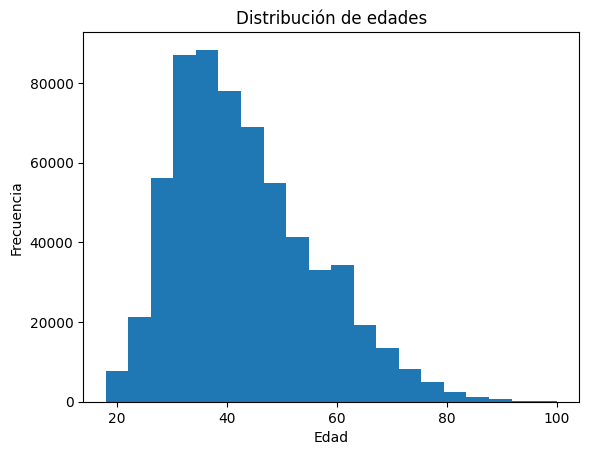

In [8]:
# Filtrar edades validas 
df = df[
    (df["Edad (años)"] >= 18) &
    (df["Edad (años)"] <= 100)
    ]

#Verificamos datos de edad
plt.hist(df["Edad (años)"], bins=20)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

In [9]:
# Revision de dimensiones despues de limpieza logica para verificar que no existen variables de tipo [Maestia, MAESTRIA, maestria]

print("------------------------------")
print(df["Nivel Académico"].unique())
print("------------------------------")
print(df["Sexo"].unique())
print("------------------------------")
print(df["Estado civil"].unique())
print("------------------------------")
print(df["Área Conocimiento"].unique())
print("------------------------------")



------------------------------
<StringArray>
[    'SIN INFORMACIÓN',            'MAESTRÍA',         'PROFESIONAL',
 'TÉCNICA PROFESIONAL',     'ESPECIALIZACIÓN',         'TECNOLÓGICA',
        'BACHILLERATO',           'DOCTORADO',             'NINGUNO',
       'UNIVERSITARIA',            'PRIMARIA']
Length: 11, dtype: str
------------------------------
<StringArray>
['FEMENINO', 'MASCULINO', 'DESCONOCIDO', 'NO_BINARIO']
Length: 4, dtype: str
------------------------------
<StringArray>
[         'DESCONOCIDO',              'SOLTERO',               'CASADO',
          'UNION_LIBRE',           'DIVORCIADO',                'VIUDO',
  'SEPARADO_MATRIMONIO', 'SEPARADO_UNION_LIBRE']
Length: 8, dtype: str
------------------------------
<StringArray>
[         'ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES',
           'CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN',
                           'CIENCIAS SOCIALES Y HUMANAS',
                                     'SALUD Y BIENESTAR',
              

In [10]:

# Debido al desbalance de clases del dataset, además de accuracy se utilizaran métricas como precision, recall y F1-score para evaluar el desempeño real del modelo.

# Aplicamos variables
X = df[
    [
        "País",
        "Edad (años)",
        "Nivel Académico",
        "Sexo",
        "Estado civil"
    ]
]

Y = df["Área Conocimiento"]

# Aplicamos one hot encoding
X = pd.get_dummies(X)
print("------------------------------")
print(X.shape)
print("------------------------------")

------------------------------
(622008, 210)
------------------------------


In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [14]:
#verificamos dimensiones
print(X_train.shape)
print(X_test.shape)

(497606, 210)
(124402, 210)


In [ ]:
# Creamos modelo de regresion logistica
modelo_log = LogisticRegression(
    max_iter = 1000
)

# entrenamos el modelo
modelo_log.fit(X_train,Y_train)

# hacemos predicciones
pred_log = modelo_log.predict(X_test)

# Hacemos evaluacion
print("=== REGRESIÓN LOGÍSTICA ===")

print(
    "Accuracy:",
    accuracy_score(Y_test, pred_log)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        pred_log,
        average="weighted",
        zero_division = 0
)
)

print(
    "Recall:",
    recall_score(
        Y_test,
        pred_log,
        average="weighted",
        zero_division = 0
    )
)

print(
    "F1-score:",
    f1_score(
        Y_test,
        pred_log,
        average="weighted",
        zero_division = 0
    )
)

c:\Users\Home\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== REGRESIÓN LOGÍSTICA ===
Accuracy: 0.2906062603495121


c:\Users\Home\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision: 0.2537406384362354
Recall: 0.2906062603495121
F1-score: 0.20487671222753098


Accuracy: 29.06%
Precision: 25.37%
Recall: 29.06%
F1-score: 20.48%

La Regresion Logistica probablemente

* favoreció clases grandes
* ignoró clases pequeñas

A demas **presentó limitaciones** debido al carácter multiclase y no linealidad del problema, además del desbalance de categorías.

In [21]:
# Creamos el modelo de Arbol
modelo_tree = DecisionTreeClassifier(
    random_state=42
)

#Entrenamos
modelo_tree.fit(X_train, Y_train)

# Aplicamos predicciones 
pred_tree = modelo_tree.predict(X_test)

print("=== ÁRBOL DE DECISIÓN ===")

print(
    "Accuracy:",
    accuracy_score(Y_test, pred_tree)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        pred_tree,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        pred_tree,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1-score:",
    f1_score(
        Y_test,
        pred_tree,
        average="weighted",
        zero_division=0
    )
)

=== ÁRBOL DE DECISIÓN ===
Accuracy: 0.25755212938698735
Precision: 0.20851841775387786
Recall: 0.25755212938698735
F1-score: 0.2175776686928871


Accuracy: 25.75%
Precision: 20.85%
Recall: 25.75%
F1-score: 21.75%

El F1-score es relativamente bajo.

Eso indica que:

* el árbol está teniendo dificultades
* posiblemente hay overfitting
* algunas clases no se distinguen bien

Los modelos base **presentaron limitaciones** debido al desbalance y complejidad multiclase del dataset

In [27]:
modelo_rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

modelo_rf.fit(X_train, Y_train)

pred_rf = modelo_rf.predict(X_test)

print("=== RANDOM FOREST ===")

print(
    "Accuracy:",
    accuracy_score(Y_test, pred_rf)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        pred_rf,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        pred_rf,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1-score:",
    f1_score(
        Y_test,
        pred_rf,
        average="weighted",
        zero_division=0
    )
)

=== RANDOM FOREST ===
Accuracy: 0.26273693348981525
Precision: 0.20950164958144196
Recall: 0.26273693348981525
F1-score: 0.21795800272797763


Durante el desarrollo del proyecto se identificó que el enfoque inicial orientado a predecir el área de conocimiento presentaba limitaciones importantes debido al alto solapamiento entre categorías, el desbalance de clases y la baja capacidad predictiva de las variables disponibles. A partir de los resultados obtenidos en los modelos de clasificación, se decidió replantear la metodología hacia un análisis de patrones migratorios y tendencias académicas, permitiendo un estudio más coherente y alineado con la naturaleza real del dataset.

# Pregunta principal
¿Qué áreas de conocimiento presentan mayor migración internacional entre los colombianos registrados en el exterior?

## Preguntas secundarias
* ¿Qué perfiles académicos presentan mayor movilidad internacional?
* ¿Qué países concentran determinadas áreas de conocimiento?
* ¿Qué rango de edad predomina según el área académica?
* ¿Existe relación entre nivel académico y migración internacional?
* ¿Qué características sociodemográficas predominan en los perfiles migratorios?

In [ ]:
# realizamos conteo de áreas de conocimiento
areas = df["Área Conocimiento"].value_counts()

print(areas)

Área Conocimiento
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             151304
INGENIERÍA, ARQUITECTURA Y AFINES                        120524
CIENCIAS DE LA SALUD                                      81778
CIENCIAS SOCIALES Y HUMANAS                               75152
BELLAS ARTES                                              34901
CIENCIAS DE LA EDUCACIÓN                                  33337
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                      28827
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                      19778
SALUD Y BIENESTAR                                         16162
MATEMÁTICAS Y CIENCIAS NATURALES                          12003
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN                9766
EDUCACIÓN                                                  6285
ARTES Y HUMANIDADES                                        6115
COCINA Y CULINARIA                                         4997
AGRONOMÍA, VETERINARIA Y AFINES                            4981
AGRONOMÍA, VETERINARIA

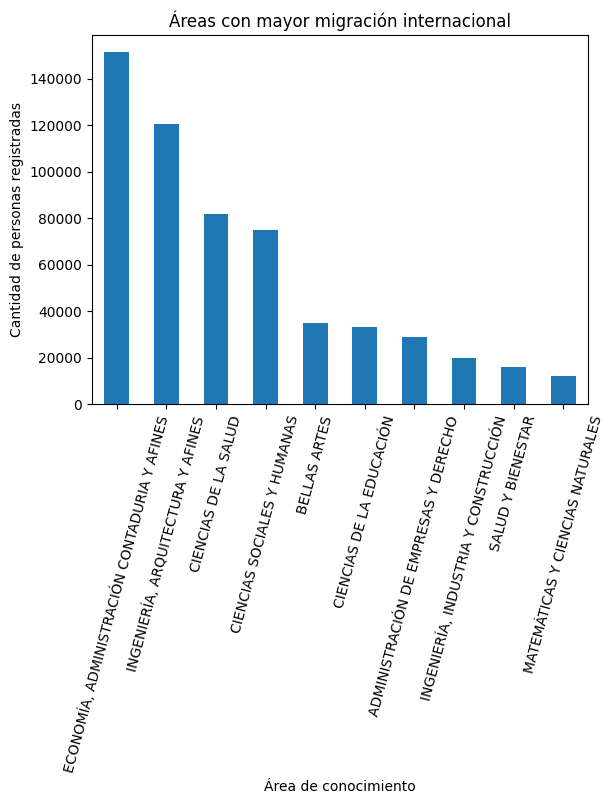

In [31]:
# Grafica de las areas mas representativas
areas.head(10).plot(kind="bar")

plt.title("Áreas con mayor migración internacional")
plt.xlabel("Área de conocimiento")
plt.ylabel("Cantidad de personas registradas")

plt.xticks(rotation=75)

plt.show()

In [ ]:
# Revisamos Valores de Nivel Academico
df["Nivel Académico"].value_counts()

Nivel Académico
SIN INFORMACIÓN        262105
PROFESIONAL            176870
TÉCNICA PROFESIONAL     69958
MAESTRÍA                40933
TECNOLÓGICA             36213
ESPECIALIZACIÓN         24669
DOCTORADO                8204
BACHILLERATO             2372
NINGUNO                   475
PRIMARIA                  190
UNIVERSITARIA              19
Name: count, dtype: int64

Al revisar el Dataset se eliminaran datos sin informacion y la seccion UNIVERSITARIA debido a que es semanticamente parecida a profesional, ademas de tener muy pocos datos

se decidio no eliminar datos de primaria debido a que los Colombianos puede tener formación técnica en
* cursos complementarios
* experiencia laboral
* formación no universitaria

sin necesariamente haber terminado bachillerato formalmente y que concuerdan con las pocas carreras que se encontraron vinculadas a esta sección.


In [36]:
niveles_invalidos = [
    "SIN INFORMACIÓN",
    "NINGUNO",
    "UNIVERSITARIA"
]

df = df[
    ~df["Nivel Académico"].isin(niveles_invalidos)
]

print(df["Nivel Académico"].value_counts())
# Verificamos el registro de datos
print(df.shape)
df["Área Conocimiento"].value_counts()

Nivel Académico
PROFESIONAL            176870
TÉCNICA PROFESIONAL     69958
MAESTRÍA                40933
TECNOLÓGICA             36213
ESPECIALIZACIÓN         24669
DOCTORADO                8204
BACHILLERATO             2372
PRIMARIA                  190
Name: count, dtype: int64
(359409, 11)


Área Conocimiento
ECONOMÍA, ADMINISTRACIÓN CONTADURIA Y AFINES             75404
INGENIERÍA, ARQUITECTURA Y AFINES                        59455
CIENCIAS DE LA SALUD                                     40742
CIENCIAS SOCIALES Y HUMANAS                              36782
ADMINISTRACIÓN DE EMPRESAS Y DERECHO                     28772
INGENIERÍA, INDUSTRIA Y CONSTRUCCIÓN                     19750
BELLAS ARTES                                             16800
SALUD Y BIENESTAR                                        16135
CIENCIAS DE LA EDUCACIÓN                                 15594
CIENCIAS SOCIALES, PERIODISMO E INFORMACIÓN               9745
EDUCACIÓN                                                 6273
ARTES Y HUMANIDADES                                       6104
MATEMÁTICAS Y CIENCIAS NATURALES                          5896
COCINA Y CULINARIA                                        4990
AGRONOMÍA, VETERINARIA Y ZOOTECNIA                        3610
TECNOLOGÍAS DE LA INFORMACIÓN Y LA CO

Aunque el número de registros se redujo considerablemente durante la depuración, esto permitió trabajar con perfiles académicos consistentes y relevantes para el análisis migratorio, eliminando registros incompletos o sin valor analítico.